In [4]:
import random
import scipy
import numpy as np
import pickle
import os
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
%matplotlib inline
tasks=['FashionMNIST_09', 'medical', 'spt','relabel', 'pca_medical']
x_trains = {}
y_trains = {}
x_tests = {}
y_tests = {}
hs_train={}
hs_test={}
os.getcwd()
data_path=os.getcwd()
plt.rcParams['font.family'] = 'Arial'
for t in tasks:
    if t == "FashionMNIST_09":
        with open(data_path+'/dataset/FashionMNIST_09_all.pkl','rb') as f:
            data_FashionMNIST_09=pickle.load(f)
            x_trains['FashionMNIST_09'] = data_FashionMNIST_09['x_train']
            y_trains['FashionMNIST_09'] = data_FashionMNIST_09['y_train']
            x_tests['FashionMNIST_09'] = data_FashionMNIST_09['x_test']
            y_tests['FashionMNIST_09'] = data_FashionMNIST_09['y_test']

    elif t == 'spt':
        with open(data_path+'/dataset/spt_all.pkl', 'rb') as f:
            data_all=pickle.load(f)
        x_trains['spt'] = data_all['x_train'][:,:270]
        y_trains['spt'] = data_all['y_train']
        x_tests['spt'] = data_all['x_test'][:,:270]
        y_tests['spt'] = data_all['y_test']
        hs_train['spt']=data_all['x_train'][:,-1]
        hs_test['spt']=data_all['x_test'][:,-1]

    elif t == 'relabel':
        with open(data_path+'/dataset/relabeled_pca_FashionMNIST_09_exp.pkl', 'rb') as f:
            data_all=pickle.load(f)
        x_trains['relabel'] = data_all['x_train']
        y_trains['relabel'] = data_all['y_train']
        x_tests['relabel'] = data_all['x_test']
        y_tests['relabel'] = data_all['y_test']

    elif t == "medical":
        with open(data_path+'/dataset/medical_all.pkl', 'rb') as f:
            data_medical=pickle.load(f)
        x_trains['medical'] = data_medical['x_train']
        y_trains['medical'] = data_medical['y_train']
        x_tests['medical'] = data_medical['x_test']  
        y_tests['medical'] = data_medical['y_test']
    elif t == 'pca_medical':
        with open(data_path+'/dataset/pca_medical_all.pkl', 'rb') as f:
            data_medical=pickle.load(f)
        x_trains['pca_medical'] = data_medical['pca_x_train']
        y_trains['pca_medical'] = data_medical['y_train']
        x_tests['pca_medical'] = data_medical['pca_x_test']  
        y_tests['pca_medical'] = data_medical['y_test']

In [5]:
def plot_ecdf(x,
              ax=None,
              mean=True,
              median=False,
              xlabel='',
              **kwargs):
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111)
    x = np.sort(x)
    y = np.arange(len(x)) / len(x)
    if 'label' in kwargs:
        label = kwargs.pop('label')
    else:
        label = ''
    ax.step(np.hstack([x, x[-1]]), np.hstack([y, 1]), **kwargs)
    if mean:
        ylim = plt.ylim()
        _mean = np.mean(x)
        ax.plot([_mean] * 100,
                np.linspace(ylim[0], ylim[1], 100),
                ls='--',
                color=ax.lines[-1].get_c(),
                alpha=ax.lines[-1].get_alpha(),
                label=label )
    if median:
        ylim = plt.ylim()
        _median = np.median(x)
        ax.plot([_median] * 100,
                np.linspace(ylim[0], ylim[1], 100),
                ls='-.',
                color=ax.lines[-1].get_c(),
                alpha=ax.lines[-1].get_alpha(),
                label=label)
    plt.ylim(0, 1)
    plt.ylabel('ECDF', fontsize=14)
    plt.xlabel(xlabel, fontsize=14)
    plt.tick_params(labelsize=12)
    plt.legend(fontsize=14)
    plt.tight_layout()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

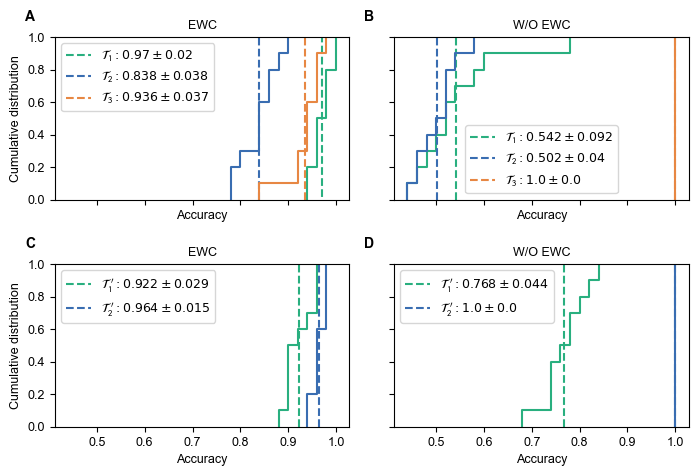

In [6]:
PAPERFIGURE = np.array([180, 247]) / 25.4  # nature
qnums=[18,10]
plot_hist=False
save=True
filenames={
            '18':[data_path+r'/results/18q_EWC_set_num50.pkl',
                    data_path+r'/results/18q_NO_EWC_set_num50.pkl'],
            '10':[data_path+r'/results/10q_EWC_set_num50.pkl',
                    data_path+r'/results/10q_NO_EWC_set_num50.pkl']
            }
reses_all={}
for qnum in qnums:
    reses_all[qnum]=[]
    for i in range(2):
        with open(filenames[f'{qnum}'][i],'rb') as f:
            d=pickle.load(f)
            reses_all[qnum].append(d)
fig,axs = plt.subplots(2,2,figsize=[PAPERFIGURE[0],PAPERFIGURE[1]/2],sharex=True,sharey=True)
des=[f'EWC',f'W/O EWC']
fig_label = ['A','B','C','D']
fontsize=9
for edx,qnum in enumerate(qnums):
    for index,res in enumerate(reses_all[qnum]):
        accs=res['accs']
        i=1
        cs=['#29af7f','#396db1',[231/255, 135/255, 67/255]]
        ax = axs[edx,index]
        for task,acc in accs.items():
            step = 67 if qnum == 18 else 36
            _acc=acc[step]
            # _acc,count = np.unique(_acc,return_counts=True)
        
            mean= round(np.mean(_acc),3)
            std = round(np.std(_acc),3)
            if edx==0:
                label=fr'$\mathcal{{T}}_\mathcal{{{i}}}:{mean}\pm {std}$'
            else:
                label=fr'$\mathcal{{T}}_\mathcal{{{i}}}^{{\ \prime}}:{mean}\pm {std}$'
            if plot_hist:
                ax.hist(_acc,color=cs[i-1],label=label,bins=3,alpha=0.5)
                ax.set_xlabel('Label',fontsize=fontsize)
                ax.set_ylabel('Count',fontsize=fontsize)
            else:
                plot_ecdf(_acc,color=cs[i-1],label=label,ax=ax)
                ax.set_xlabel('Accuracy',fontsize=fontsize)
                if index==1:
                    ax.set_ylabel('')
                else:
                    ax.set_ylabel('Cumulative distribution',fontsize=fontsize)
            i+=1
            ax.set_title(des[index],fontsize=fontsize)
            ax.legend(fontsize=fontsize)
            ax.tick_params(labelsize=fontsize)
        ax.text(0.35,1.1,fig_label[edx*2+index],fontsize=fontsize+1,fontweight='bold')
        # plt.tight_layout()  # 参数可调至0.1参数可调至0.1
    if save:
        file_name =data_path+f'/last_step_distirbution.pdf'
        plt.savefig(
            file_name,
            dpi=300,
            facecolor='w',
            edgecolor='w',
            orientation='portrait',
            format='pdf',
        )